# DC Motor Controller Synthesis

## Overview

This notebook performs **1st order DC motor model identification and LQG controller synthesis** for a brushed/brushless DC motor.

The motor is modelled as a first-order system:

$$\tau \dot{\omega} = -\omega + k \cdot u$$

where:
- $\omega$ — angular velocity [rad/s]
- $u$ — control input (normalised, $0 \ldots 1$)
- $k$ — motor constant [rad/s per unit input]
- $\tau$ — motor time constant [s]

## Identification Procedure

Two parameters need to be identified from hardware measurements:

### 1. Motor constant $k$ — steady-state gain
For several input levels $u \in \{0.2, 0.3, \ldots, 1.0\}$, the motor was driven at constant input and the steady-state velocity was measured. The motor constant is computed as:

$$k = \frac{\omega_{ss}}{u}$$

The individual estimates are averaged to obtain a single $k$. The variance of the encoder reading is also recorded to characterise sensor noise.

**Advantages over textbook single-point measurement:**
- By sweeping multiple input levels, we obtain a **statistical average** of $k$, reducing the effect of measurement noise on any single operating point.
- We also directly observe the **nonlinearity** of the motor (the per-input $k$ decreases at higher inputs due to saturation, friction, back-EMF effects), giving us confidence in the linear model's validity range.
- The encoder noise variance $\sigma^2$ is measured **simultaneously** — no separate noise characterisation experiment is needed. This variance feeds directly into the Kalman filter design.

### 2. Time constant $\tau$ — relay oscillation method
Instead of fitting an exponential step response (textbook approach, sensitive to noise and initial conditions), we use a **relay feedback method**:
- A relay (bang-bang) controller drives the motor into sustained oscillations.
- The oscillation period is measured over many cycles (309 periods in our case), giving a very precise estimate of $\tau$.

**Why this is better than the textbook step-response method:**

| | Textbook (step response) | Relay oscillation (our method) |
|---|---|---|
| **Data used** | Single transient, a few samples near $0.632 \cdot \omega_{ss}$ | 309 full oscillation periods |
| **Noise sensitivity** | High — a few noisy samples shift the $\tau$ estimate significantly | Very low — averaging over hundreds of periods cancels noise |
| **Requires steady-state knowledge** | Yes — must know $\omega_{ss}$ precisely to find $63.2\%$ point | No — only oscillation period matters |
| **Bias from friction / deadzone** | Significant at low velocities | Self-correcting — relay amplitude can be chosen to stay in linear region |
| **Precision** | Typically $\pm 20\text{–}50\%$ | Sub-millisecond accuracy with enough periods |

The relay method essentially converts a **time-domain estimation problem** (find when the signal crosses a threshold) into a **frequency-domain measurement** (measure a period), which is inherently more robust to noise.

## Raw Measurements

Below are the raw terminal outputs from the identification experiment.

```
machine ready
u_in   =  0.200
k      =  336.425
rpm    = 642
x_mean =  67.285
x_var  =  54.743

u_in   =  0.300
k      =  306.436
rpm    = 877
x_mean =  91.930
x_var  =  98.451

u_in   =  0.400
k      =  262.535
rpm    = 1002
x_mean =  105.014
x_var  =  175.590

u_in   =  0.500
k      =  239.385
rpm    = 1142
x_mean =  119.692
x_var  =  208.611

u_in   =  0.600
k      =  219.558
rpm    = 1257
x_mean =  131.735
x_var  =  206.218

u_in   =  0.700
k      =  199.122
rpm    = 1331
x_mean =  139.386
x_var  =  221.974

u_in   =  0.800
k      =  184.088
rpm    = 1406
x_mean =  147.270
x_var  =  209.316

u_in   =  0.900
k      =  167.702
rpm    = 1441
x_mean =  150.932
x_var  =  276.960

u_in   =  1.000
k      =  154.379
rpm    = 1474
x_mean =  154.379
x_var  =  321.025

k          =  206.963
x_var_mean =  177.289

periods = 309
tau     =  6.047[ms]
```

**Notes:**
- `x_mean` and `x_var` are the mean and variance of the angular velocity in rad/s, measured from the encoder.
- The per-input $k$ values decrease at higher inputs due to motor saturation / nonlinearity — the averaged value $k = 206.963$ is used as a linear approximation.
- The encoder noise variance (averaged across all operating points) is $177.289 \; (\text{rad/s})^2$.
- The time constant $\tau = 6.047 \; \text{ms}$ was estimated from 309 relay oscillation periods — providing high confidence in the estimate.

## 1. Plant Model

Define the continuous-time state-space model and discretise it at the sampling frequency $f_s = 2 \; \text{kHz}$.

$$\dot{x} = A x + B u, \quad y = C x$$

with $A = -1/\tau$, $B = k/\tau$, $C = 1$.

In [1]:
import AILibs
import numpy
import matplotlib.pyplot as plt


#parameters from identification

#sampling frequency, 2kHz
dt       = 1.0/2000.0


u_max       =  1.0          # torque max value
k           =  173.747      # motor constant 
rad_var     =  115.570      # (rad/s)^2 variance (encoder noise)
tau         =  7.321        # motor time constant, milliseconds



rpm_max = u_max*k*60.0/(2.0*numpy.pi)

print("rpm_max = ", rpm_max)


# continuous time dynamics, 2st order DC motor model
mat_a = numpy.zeros((1, 1))
mat_b = numpy.zeros((1, 1))
mat_c = numpy.eye(1)
 
tau = tau*0.001
mat_a[0][0] = -1.0/tau    
mat_b[0][0] = k*(1.0/tau)


print("continuous model")
print("a = ", mat_a)
print("b = ", mat_b)
print()


#create continuous dynamical system (state space model)
ds = AILibs.DynamicalSystem(mat_a, mat_b, mat_c, dt)

print(ds)



rpm_max =  1659.1616338432527
continuous model
a =  [[-136.59336156]]
b =  [[23732.68679142]]

mat_a = 
-136.59336 


mat_b = 
23732.68679 


mat_c = 
1.0 





## 2. Open-Loop Step Response

Verify the identified model by simulating the unit step response. The motor should reach steady-state velocity $\omega_{ss} = k \cdot u$ within a few time constants ($\approx 5\tau \approx 30 \; \text{ms}$).

<Figure size 640x480 with 0 Axes>

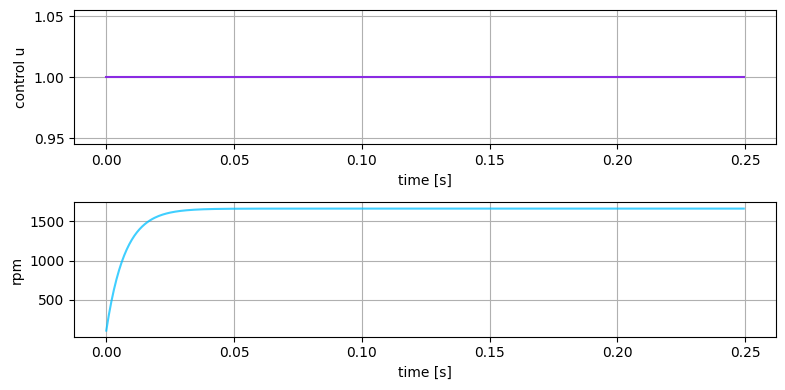

In [2]:


#compute step response
t_result = []
u_result = []
x_result = []

for n in range(500):

    # unit step as input
    u = numpy.ones((1, 1))

    x, _ = ds.forward_state(u)

    t_result.append(n*dt)
    u_result.append(u[:, 0])
    x_result.append(x[:, 0])

t_result = numpy.array(t_result)
x_result = numpy.array(x_result)

#plot result
AILibs.plot_response(t_result, u_result,  x_result*60.0/(2.0*numpy.pi), "plots/step_response.png", ["control u"], ["rpm"])



## 3. LQG Controller Synthesis

Design a **Linear Quadratic Gaussian (LQG)** controller, which combines:

- **LQR (Linear Quadratic Regulator)** — optimal state feedback with integral action for zero steady-state error.
- **Kalman Filter (steady-state)** — optimal state observer to filter encoder noise.

### LQR with integral action

The LQR minimises the cost function:

$$J = \sum_{k=0}^{\infty} \left( x_k^T Q \, x_k + u_k^T R \, u_k \right)$$

The state is augmented with an integral of the tracking error $e_I = \sum (y_r - y)$, so the controller produces two gains:
- $K$ — state feedback gain
- $K_i$ — integral gain (ensures zero steady-state error and disturbance rejection)

### Steady-state Kalman filter

In the textbook formulation, the Kalman filter computes a **time-varying** gain $F_k$ at each step by propagating the error covariance matrix $P_k$ via the Riccati recursion. This is computationally expensive and unnecessary when:

1. The system is **linear time-invariant** (LTI) — our motor model does not change over time.
2. The noise covariances $Q_{\text{noise}}$ and $R_{\text{noise}}$ are **constant** — the encoder noise variance and process uncertainty do not change during operation.

Under these conditions, the covariance $P_k$ converges to a **steady-state** value $P_\infty$, and the Kalman gain converges to a constant matrix $F$. We compute $F$ offline by solving the **Discrete Algebraic Riccati Equation (DARE)** — the same type of equation used for LQR.

This gives us a **fixed-gain observer** that is:
- **Optimal** — identical performance to the full time-varying Kalman filter (after the brief initial transient).
- **Trivial to implement on MCU** — just a constant matrix multiply, no online Riccati recursion, no matrix inversion at runtime.
- **Deterministic execution time** — important for real-time control at 2 kHz.

The resulting controller update at each timestep is simply:

$$\hat{x}_{k+1} = A \hat{x}_k + B u_k + F (y_k - C \hat{x}_k)$$
$$u_k = -K \hat{x}_k + K_i e_{I,k}$$

This is just a few multiply-accumulate operations — easily runs in microseconds on any modern microcontroller.

### Tuning parameters:
- **Q** — state penalty matrix (how aggressively to track the reference)
- **R** — control effort penalty (higher $R$ → smoother, slower response; lower $R$ → faster, more aggressive)
- **Q_noise** — process noise covariance (captures model uncertainty, unmodelled dynamics)
- **R_noise** — observation noise covariance (encoder noise, directly from identification: $\sigma^2 = 177.289 \; (\text{rad/s})^2$)

The controller is designed in discrete time, matching the 2 kHz sampling rate.

In [3]:
# controller syntehtize : LQR + Klaman = LQG controller

#create loss weighting matrices (diagonal)
q = numpy.array([ [1.0] ] )
#r = numpy.array( [ [1*(10**7)] ]) 
r = numpy.array( [ [5*(10**8)] ]) 

#process and observation noise covariance
q_noise = 2*numpy.eye(ds.a.shape[0]) 
r_noise = (rad_var)*numpy.eye(ds.c.shape[0]) 
    

a_disc, b_disc, c_disc = AILibs.c2d(ds.a, ds.b, ds.c, dt)

print("discrete model")
print("a = ", a_disc)
print("b = ", b_disc)
#print()
#print("poles")
#print(numpy.linalg.eigvals(a_disc))
print("\n")

#solve LQG controller
lqg = AILibs.LQGDiscrete(a_disc, b_disc, c_disc, q, r, q_noise, r_noise)

print("controller gains")
print("k  = ", lqg.k)
print("ki = ", lqg.ki)

# kalman gain
print("f  = ", lqg.f)


discrete model
a =  [[0.93395853]]
b =  [[11.47450799]]


[[1.]]
[[500000000]]
controller gains
k  =  [[0.00064245]]
ki =  [[4.45568037e-05]]
f  =  [[0.08042387]]


## 4. Closed-Loop Simulation

Test the LQG controller in simulation:

- **Reference:** 500 RPM step command
- **Disturbance:** At $t = 0.5 \; \text{s}$ (midpoint), a constant disturbance of $+0.25$ is added to the control input — simulating an external torque load.

The controller should:
1. Track the 500 RPM reference with zero steady-state error (integral action).
2. Reject the step disturbance and return to the commanded velocity.

<Figure size 640x480 with 0 Axes>

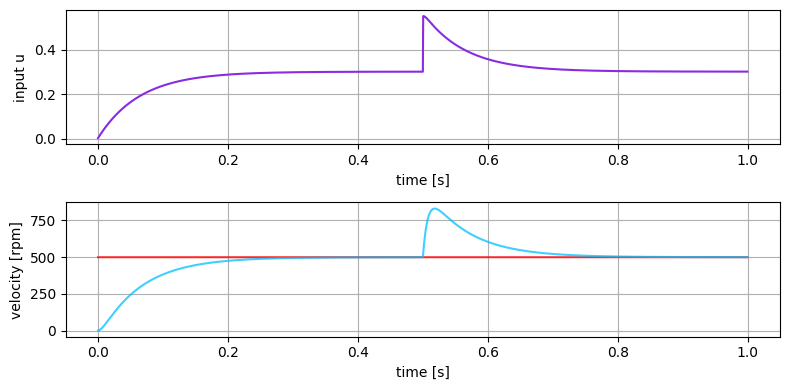

In [4]:

#process simulation - test controller

n_max = 2000

#required output, 500rpm
rpm_req = 500

yr = numpy.zeros((mat_c.shape[0], 1))
yr[0][0] = (rpm_req/60.0)*(2.0*numpy.pi) 


#observed state
x_hat = numpy.zeros((mat_a.shape[0], 1))



#initial error integral
integral_action = numpy.zeros((mat_b.shape[1], 1))

#result log
t_result = []
u_result = []
u_in_result = []
xr_result = []
x_result = []



#initial motor state
ds.reset()

#plant output
y = ds.y


for n in range(n_max):

    #compute controller output
    u, integral_action, x_hat = lqg.forward(yr, y, integral_action, x_hat)
    
    u_in = u.copy()

    #add constant disturbance in middle
    if n > n_max//2:
        u_in[0]+= 0.25
 
    #compute plant output
    x, y = ds.forward_state(u_in)
  
    

    t_result.append(n*dt)
    u_result.append(u[:, 0].copy())
    u_in_result.append(u_in[:, 0].copy())
    xr_result.append(yr[:, 0].copy())
    x_result.append(x[:, 0].copy())

    
    
t_result = numpy.array(t_result)
xr_result = numpy.array(xr_result)
x_result = numpy.array(x_result)
u_result = numpy.array(u_result)
u_in_result = numpy.array(u_in_result)

#convert rps to rpm
xr_result[:, 0]*= 60.0/(2.0*numpy.pi)
x_result[:, 0]*= 60.0/(2.0*numpy.pi)

#plot results
AILibs.plot_cl_response(t_result, u_in_result, xr_result, x_result, "plots/lqg_result.png",  ["input u"], ["velocity [rpm]"])
